# Task 1 — Population Distribution Analysis (World Bank Dataset)

**SkillCraft Technology — Data Science Internship**
**Repository:** SCT_DS_1

## Objective
Create a **Bar Chart** and a **Histogram** to visualize the distribution of the world's
population using the World Bank "Population, total" indicator (`SP.POP.TOTL`).

## Dataset
- Source: [World Bank Open Data — Population, total](https://data.worldbank.org/indicator/SP.POP.TOTL)
- File used: `API_SP.POP.TOTL_DS2_EN_csv_v2_3107.csv`
- Supporting file: `Metadata_Country_API_SP.POP.TOTL_DS2_EN_csv_v2_3107.csv` (used to separate
  real countries from regional/income aggregates such as "World" or "Arab World")

## What this notebook covers
1. Load and inspect the raw data
2. Clean the data (remove aggregate rows, handle missing values)
3. Bar Chart — Top 10 most populous countries
4. Histogram — Distribution of population across all countries
5. Insights and Conclusion


## Step 1: Import Libraries

We import three libraries:
- **pandas** — to load the CSV and clean/reshape the data (tables, filtering, sorting).
- **matplotlib.pyplot** — the base plotting engine; gives us full control over chart details.
- **seaborn** — built on top of matplotlib, gives our charts a clean, professional look
  with less code, and is the standard for statistical plots in the data science industry.

We also set a consistent visual style once, at the top, so every chart in this notebook
looks consistent — a small habit that makes notebooks look professional.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, consistent visual theme for all charts in this notebook
sns.set_theme(style="whitegrid")

# Make charts render at a readable size and resolution by default
plt.rcParams["figure.dpi"] = 110

## Step 2: Load the Dataset

The World Bank CSV has **4 metadata lines at the top** (Data Source, Last Updated Date, a
blank line, and a note) before the real header row (`Country Name, Country Code, ...`).
If we don't skip these, pandas will misread the column names.

That's why we use `skiprows=4` — it tells pandas "ignore the first 4 lines, then start
reading the real table from line 5."

We also load the **Metadata_Country** file. This file has one row per country/region and
tells us which rows in the main file are real countries (they have a `Region` value like
"South Asia") versus aggregates like "World" or "European Union" (their `Region` field is
blank). We need this distinction — without filtering, "World" would appear as one giant bar
next to individual countries and make the chart meaningless.

In [16]:
# skiprows=4: skip the 4 non-tabular header lines at the top of the World Bank export
df = pd.read_csv("../data/API_SP.POP.TOTL_DS2_EN_csv_v2_3107.csv", skiprows=4)

# Load the country metadata file, which tells us which rows are real countries
meta = pd.read_csv("../data/Metadata_Country_API_SP.POP.TOTL_DS2_EN_csv_v2_3107.csv")

# Quick look at the shape (rows, columns) and the first few rows
print("Main dataset shape:", df.shape)
df.head()

Main dataset shape: (265, 71)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,108785.0,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,788844284.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,43844111.0,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106384410.0,108754449.0,...,440150152.0,451395343.0,462522286.0,473687685.0,484978794.0,496366058.0,508318102.0,520655398.0,532809933.0,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,39040039.0,NaN


## Step 3: Inspect the Data

Before cleaning anything, we look at the data's structure: column names, data types, and
where missing values (`NaN`) exist. This step prevents surprises later.

In [17]:
# .info() shows column names, non-null counts, and data types in one summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    265 non-null    object 
 1   Country Code    265 non-null    object 
 2   Indicator Name  265 non-null    object 
 3   Indicator Code  265 non-null    object 
 4   1960            263 non-null    float64
 5   1961            263 non-null    float64
 6   1962            263 non-null    float64
 7   1963            263 non-null    float64
 8   1964            263 non-null    float64
 9   1965            263 non-null    float64
 10  1966            263 non-null    float64
 11  1967            263 non-null    float64
 12  1968            263 non-null    float64
 13  1969            263 non-null    float64
 14  1970            263 non-null    float64
 15  1971            263 non-null    float64
 16  1972            263 non-null    float64
 17  1973            263 non-null    flo

In [18]:
# Every World Bank export ends with a stray unnamed, empty column caused by a
# trailing comma in the CSV. We check for it and will remove it in the next step.
unnamed_cols = [c for c in df.columns if "Unnamed" in c]
print("Unnamed columns found:", unnamed_cols)

Unnamed columns found: ['Unnamed: 70']


## Step 4: Data Cleaning

We clean the data in four steps:

1. **Drop the trailing unnamed column** — it's empty and adds no information.
2. **Merge with the metadata file** — this attaches a `Region` value to every row, which
   lets us tell real countries apart from aggregates.
3. **Keep only real countries** — rows where `Region` is not empty. Aggregate rows (like
   "World", "High income", "Arab World") have a blank `Region`, so we filter them out.
4. **Choose the most recent complete year and drop rows with missing values for it** — we
   checked the data ahead of time and found **2025** is the most recent year with population
   figures for nearly every country (only one non-country row was missing it, and we're
   already excluding non-countries).

In [19]:
# 1. Drop the empty trailing "Unnamed" column
df_clean = df.drop(columns=unnamed_cols)

# 2. Merge with metadata to attach each country's Region
#    how="left" keeps every row in df_clean and adds Region info where it matches
df_clean = df_clean.merge(meta[["Country Code", "Region"]], on="Country Code", how="left")

# 3. Keep only rows where Region is filled in (i.e. real countries, not aggregates)
df_clean = df_clean[df_clean["Region"].notna()].copy()

# 4. Use 2025, the most recent year with (near) complete data.
#    Drop any remaining rows where the 2025 population is missing.
YEAR = "2025"
df_clean = df_clean.dropna(subset=[YEAR])

print(f"Rows remaining after cleaning: {len(df_clean)} countries")
df_clean[["Country Name", "Country Code", "Region", YEAR]].head()

Rows remaining after cleaning: 217 countries


,Country Name,Country Code,Region,2025
0,Aruba,ABW,Latin America & Caribbean,108785.0
2,Afghanistan,AFG,Middle East & North Africa,43844111.0
4,Angola,AGO,Sub-Saharan Africa,39040039.0
5,Albania,ALB,Europe & Central Asia,2349580.0
6,Andorra,AND,Europe & Central Asia,82904.0


In [20]:
# Keep only the columns we actually need for this analysis, and give the
# population column a clearer name
population = df_clean[["Country Name", "Country Code", "Region", YEAR]].rename(
    columns={YEAR: "Population"}
)

# Make sure Population is numeric (it should already be, but this is a safe habit)
population["Population"] = pd.to_numeric(population["Population"], errors="coerce")

population.describe()

,Population
count,2.170000e+02
mean,3.775151e+07
std,1.434540e+08
min,9.492000e+03
25%,8.386450e+05
50%,6.549143e+06
75%,2.761441e+07
max,1.463866e+09


## Step 5: Bar Chart — Top 10 Most Populous Countries (2025)

A **bar chart** is the right choice here because we're comparing a **categorical variable**
(country names) against a numeric value (population). Each bar's height represents one
country's population, making it easy to compare countries side by side.

We show the **Top 10** rather than all 217 countries — with that many countries, labels
would overlap and the chart would be unreadable. Showing the top 10 keeps it clear and
highlights the most meaningful comparison.

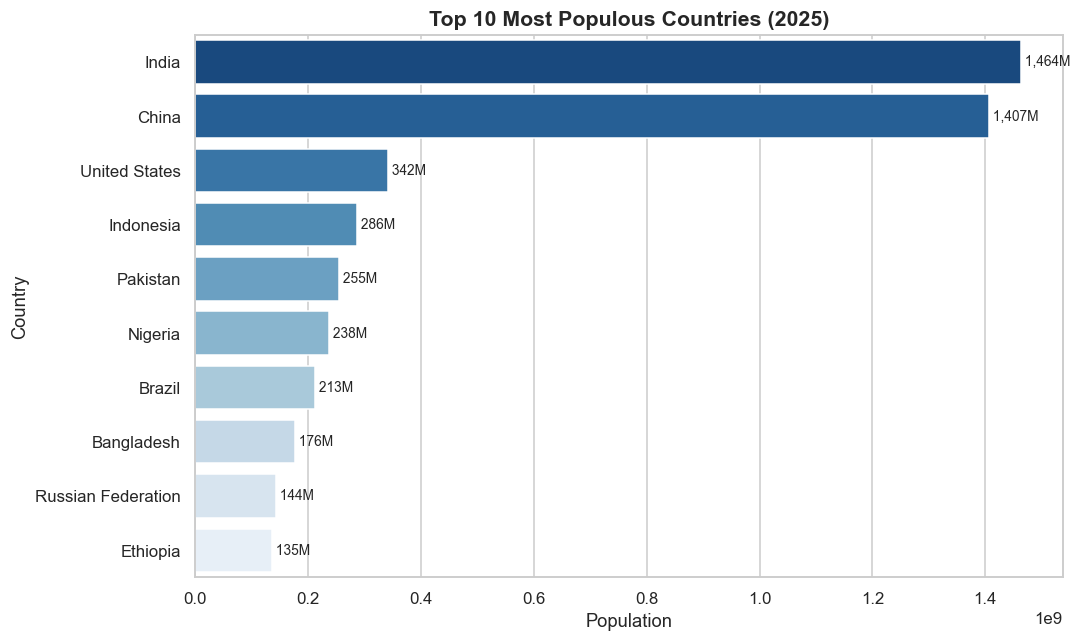

In [21]:
# Sort countries by Population (highest first) and take the top 10
top10 = population.sort_values("Population", ascending=False).head(10)

# Create the figure and axis with a set size (width, height in inches)
fig, ax = plt.subplots(figsize=(10, 6))

# barplot: x = population value, y = country name (horizontal bars read more easily
# when country names are long)
sns.barplot(
    data=top10,
    x="Population",
    y="Country Name",
    hue="Country Name",
    palette="Blues_r",
    legend=False,
    ax=ax,
)

# Format the x-axis in billions/millions for readability instead of raw numbers
ax.set_xlabel("Population")
ax.set_ylabel("Country")
ax.set_title("Top 10 Most Populous Countries (2025)", fontsize=14, fontweight="bold")

# Add the exact population value at the end of each bar
for i, value in enumerate(top10["Population"]):
    ax.text(value, i, f" {value/1e6:,.0f}M", va="center", fontsize=9)

plt.tight_layout()

# Save the chart as an image file for the README and GitHub
plt.savefig("../images/bar_chart_top10_population.png", bbox_inches="tight")
plt.show()

## Step 6: Histogram — Distribution of Population Across All Countries (2025)

A **histogram** is the right tool here because Population is a **continuous variable**, and
we want to see its overall *distribution* — how many countries fall into different
population ranges — rather than comparing named categories.

Because a few countries (India, China, USA) have populations in the billions/hundreds of
millions while most countries have just a few million people, plotting this on a normal
scale would squash almost every bar into one corner. We apply a **log scale** on the x-axis,
which is standard practice for this kind of highly skewed data — it lets us see the full
spread clearly.

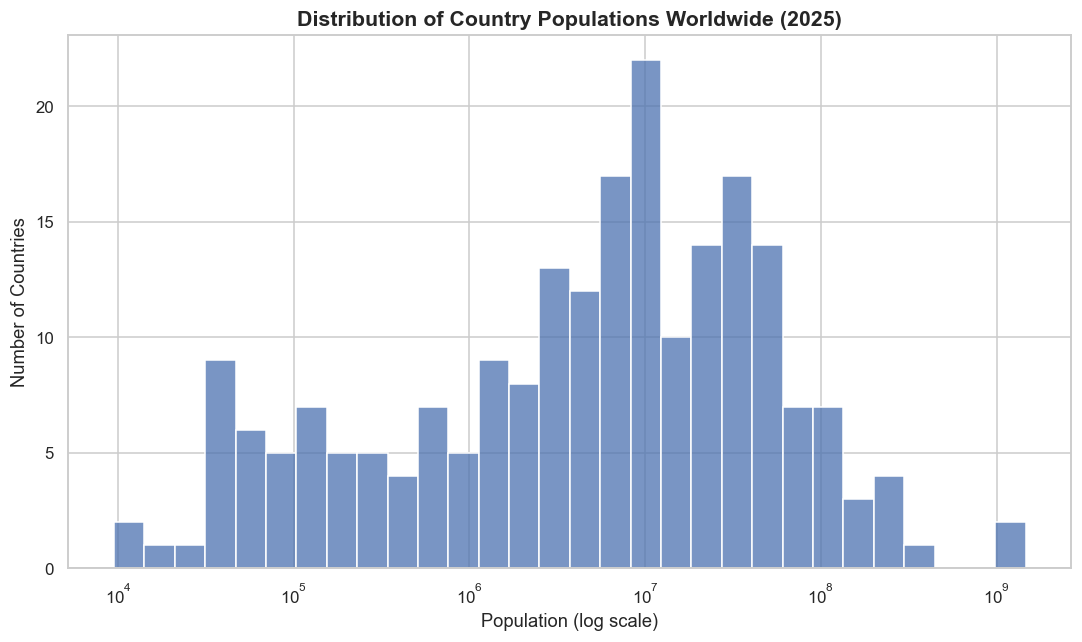

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

# histplot draws the histogram; log_scale=True bins and displays the x-axis on a
# logarithmic scale, which is the standard approach for skewed data like population
sns.histplot(data=population, x="Population", bins=30, log_scale=True, color="#4C72B0", ax=ax)

ax.set_xlabel("Population (log scale)")
ax.set_ylabel("Number of Countries")
ax.set_title("Distribution of Country Populations Worldwide (2025)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../images/histogram_population_distribution.png", bbox_inches="tight")
plt.show()

## Step 7: Insights

Based on the charts above:

- **India and China dominate global population**, together accounting for a huge share of
  the world's people — each has well over 1 billion residents, far ahead of the
  third-largest, the United States (~340 million).
- **The distribution is heavily right-skewed.** Most of the world's 217 countries have
  relatively small populations (the median is about 6.5 million), while a handful of large
  countries pull the average far higher than the median — a classic sign of skewed data.
- **Population is concentrated in a few countries.** The top 10 countries alone represent a
  disproportionate share of the world's total population, while the majority of countries
  contribute comparatively small numbers individually.
- Using a **log scale** for the histogram was necessary — on a normal scale, the handful of
  billion-plus countries would compress nearly all other countries into a single bar,
  hiding the true shape of the distribution.

## Conclusion

This analysis visualized the global population distribution using the World Bank's 2025
population dataset. After cleaning the data — removing regional aggregates and missing
values — a bar chart revealed which individual countries are most populous, while a
histogram showed that population size across countries is highly unequal and right-skewed,
with most countries clustering at the lower end and a small number of countries holding
extremely large populations. This kind of distribution is common in real-world data
(income, city sizes, company revenues) and understanding it is a foundational data science
skill.
